In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

## Fetching data

In [3]:
bike_data_source = fetch_ucirepo(id=560)
bike_df = bike_data_source.data.original
bike_df

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


## Changing data formats

In [25]:
#changing the date format and splitting them
bike_df["Date"] = pd.to_datetime(bike_df["Date"], format="%d/%m/%Y")
bike_df['year'] = bike_df["Date"].dt.year
bike_df['month'] = bike_df["Date"].dt.month
bike_df['month_name'] = bike_df["Date"].dt.month_name()
bike_df['weekday'] = bike_df["Date"].dt.dayofweek + 1
bike_df['weekday_name'] = bike_df["Date"].dt.day_name()
bike_df['day'] = bike_df["Date"].dt.day

In [26]:
#converting circular data to their respective coordinates

# Hour (0–23)
bike_df["hour_sin"] = np.sin(2 * np.pi * bike_df["Hour"] / 24)
bike_df["hour_cos"] = np.cos(2 * np.pi * bike_df["Hour"] / 24)

# Day of week 
bike_df["dow_sin"] = np.sin(2 * np.pi * bike_df["weekday"] / 7)
bike_df["dow_cos"] = np.cos(2 * np.pi * bike_df["weekday"] / 7)

# Month (1–12)
bike_df["month_sin"] = np.sin(2 * np.pi * bike_df["month"] / 12)
bike_df["month_cos"] = np.cos(2 * np.pi * bike_df["month"] / 12)

## Rented bikes in one day

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

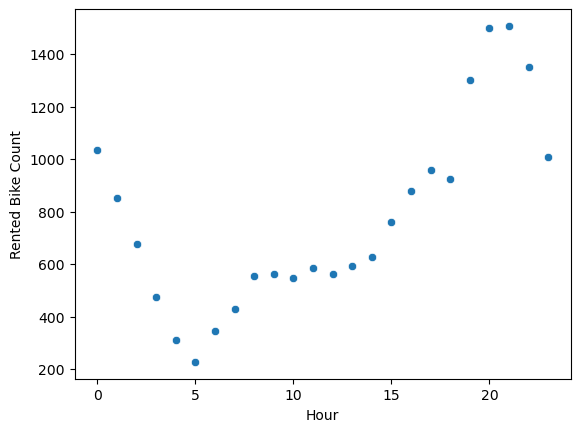

In [27]:
## create a plot with the count of rented bikes for one single day, just choose one day
day_df = bike_df.copy()
day_df = day_df.loc[(day_df["month"]==8)& (day_df["day"]==15)]


sns.scatterplot(x="Hour",y="Rented Bike Count",data=day_df)

Select the date you want to plot

## Group the data by month

In [28]:
## group the dataframe to get average counts per day
    #grouping dataframe to get average counts per day

grouped_df = (
    bike_df.copy()
      .groupby(["Date","year", "Seasons","month_name", "day","weekday", "weekday_name","Holiday"])
      .mean(numeric_only=True)       # mean for all numeric columns
      .round(2)
      .reset_index()
)


drop_columns = ["Hour", "month"]
grouped_df = grouped_df.drop(drop_columns, axis=1)

discrete_columns = ["Rented Bike Count","Humidity", "Visibility"]
grouped_df[discrete_columns] = grouped_df[discrete_columns].round(0).astype(int)

<Axes: xlabel='day'>

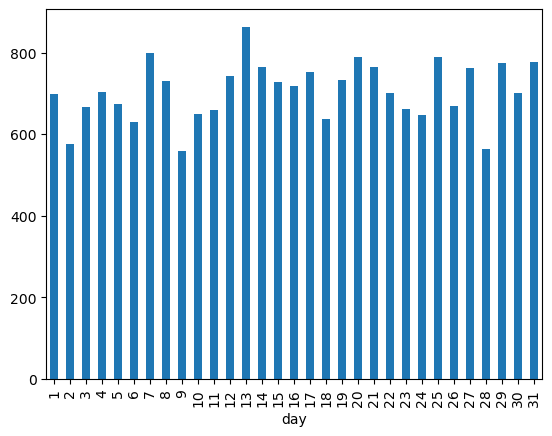

In [34]:
daily_avg = bike_df.groupby("day")["Rented Bike Count"].mean()
daily_avg.plot(kind = "bar")

<Axes: xlabel='day', ylabel='Rented Bike Count'>

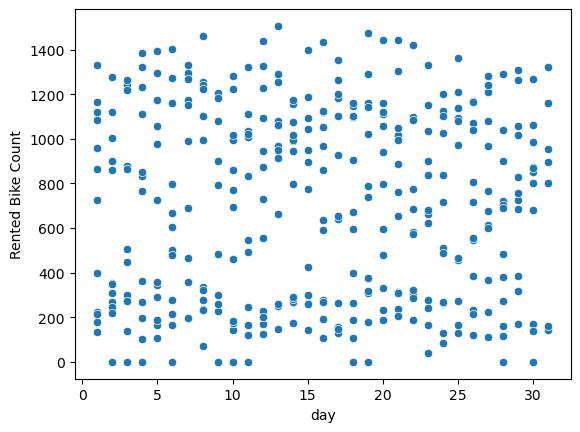

In [30]:
sns.scatterplot(x="day",y="Rented Bike Count",data=grouped_df)

In [ ]:
## create a plot with the count average count of rented bikes per month


## Check the colinearity of your predictors

In [ ]:
## create scatter plots and/or the Variance Inflation Factor


## Splitting the data

In [ ]:
## create a copy of the dataframe

## rename the columns that have white spaces

## split using the function from sklearn

## concatenate X_train and y_train into a dataframe, and concatenate X_test and y_test into another dataframe

train = pd.concat([X_train, y_train], axis=1)


## Run the model

In [ ]:
## Add constant using sm.add_constant function

## Use sm.GLM function and assign it into the a variable called "model"


## Save the fit function as result = model.fit()

In [ ]:
## Print summary()



In [ ]:
## get the following paramenters deviance, null deviance, llf, aic

## calculate the Deviance Explained 1 - (result.deviance / result.null_deviance)


## Predict

In [ ]:
## use result.predict() function


## plot the residuals

In [ ]:
## plot the actual values vs predicted values

